# Image basics

In this tutorial, we'll provide an overview of the concepts and classes that 
represent medical images in the `imfusion-sdk` and how to work with them.

## Notebook bootstrap


In [1]:
import sys
from pathlib import Path

shared_dir = next(path / "shared" for path in [Path.cwd(), *Path.cwd().parents] if (path / "shared").is_dir())
if str(shared_dir) not in sys.path:
    sys.path.append(str(shared_dir))

from demo_utils import unzip_folder


## Import modules

In [2]:
import imfusion
import numpy as np


## Image classes

- `SharedImage`: class holding a single image, either a 2D image (X-Ray, Ultrasound) or a 3D volume (CT, NM, MR, ...). The word "Shared" refers to the fact that it can have multiple representations on different devices (typically CPU + GPU via OpenGL), which are kept automatically in sync.
- `SharedImageSet`: a set of `SharedImage`s. This is the main entry point of any method in the ImFusion SDK that operates on image data. For volumetric data, a `SharedImageSet` mostly comprises a single `SharedImage` representing a volume (i.e., a CT), but it is fundamental for holding image series consisting of multiple frames, which have no trivial 3D representation, i.e., an ultrasound acquisition, an OCT pullback, Fluoro navigation, 4D-CT, and so on.
- `ImageDescriptor`: class describing the basic properties of an image, like its storage type (int, float, ...), its spacing, and its shape.
- `Matrix`: orientation of the image data in the physical world.

## Loading Images
- Since ImFusion files (.imf) can contain multiple `SharedImageSet`s, loading an `.imf` file returns a list of `SharedImageSet` objects.
- A `SharedImageSet` itself also behaves like a Python sequence, meaning you can iterate over it or access individual images by index.

In [3]:
unzipped_folder = unzip_folder("../shared/data/pet-ct-rtstruct.zip")

pet, *_ = imfusion.io.load('../shared/data/pet-ct-rtstruct/pet.imf')
labels, *_ = imfusion.io.load('../shared/data/pet-ct-rtstruct/tumors.imf')

print('PET: ', pet)
print('Labels: ', labels)

# Each of the loaded SharedImageSets contains one image.
print(f'Num of images in PET: {len(pet)}, num of images in Labels: {len(labels)}')

# Get the SharedImage from the SharedImageSet.
image = pet[0]
print('SharedImage:', image)

PET:  imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(FLOAT width: 192 height: 192 slices: 227 spacing: 3.64583x3.64583x3.27 mm)])
Labels:  imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(UBYTE width: 192 height: 192 slices: 227 spacing: 3.64583x3.64583x3.27 mm)])
Num of images in PET: 1, num of images in Labels: 1
SharedImage: imfusion.SharedImage(FLOAT width: 192 height: 192 slices: 227 spacing: 3.64583x3.64583x3.27 mm)


## Visualizing Images

To visualize an image, simply type `imfusion.show()`.

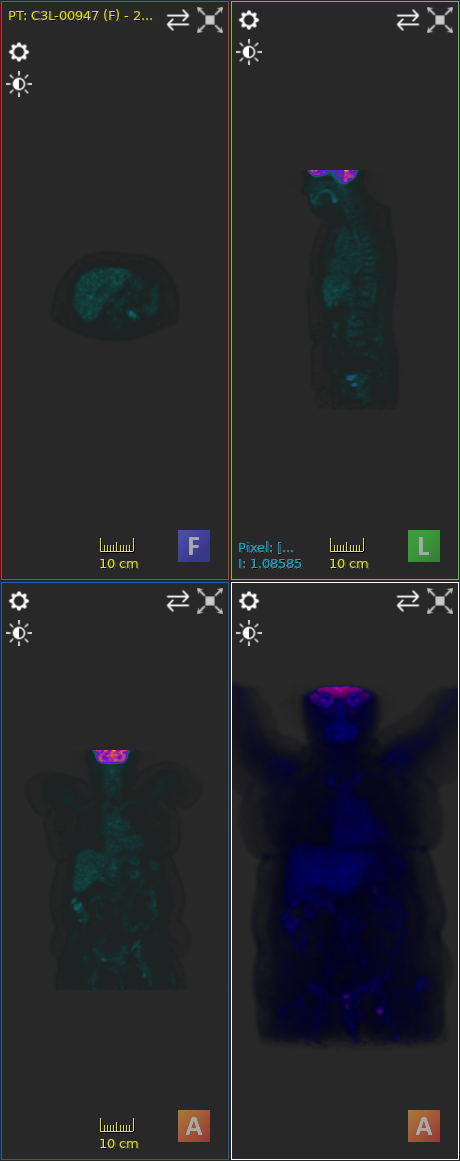

In [4]:
imfusion.show(pet, title="PET")

The `ImageDescriptor` describes the properties of an image.
In addition, each `SharedImage` stores information about the image's modality.

In [5]:
print(image.descriptor, '\n')
print(image.modality)
print(labels[0].modality)

imfusion.BoundImageDescriptor(dimensions: [w:192, h:192, s:227, c:1] | spacing:[3.64583, 3.64583, 3.27] | isMetric:true | type:FLOAT | memory: 31.92 MB) 

Modality.NM
Modality.LABEL


## Accessing image data with numpy

`SharedImage` and `SharedImageSet` provide seamless interoperability with NumPy. Images can be converted to and from `numpy.ndarray` objects using the standard NumPy interface.

A `SharedImage` is represented as a NumPy array whose dimensions correspond to `(slices, height, width, channels)`.
> **Note:** Leading dimensions of size 1 are omitted, while the channel dimension is always retained.

Shape(slices=227, height=192, width=192, channels=1)


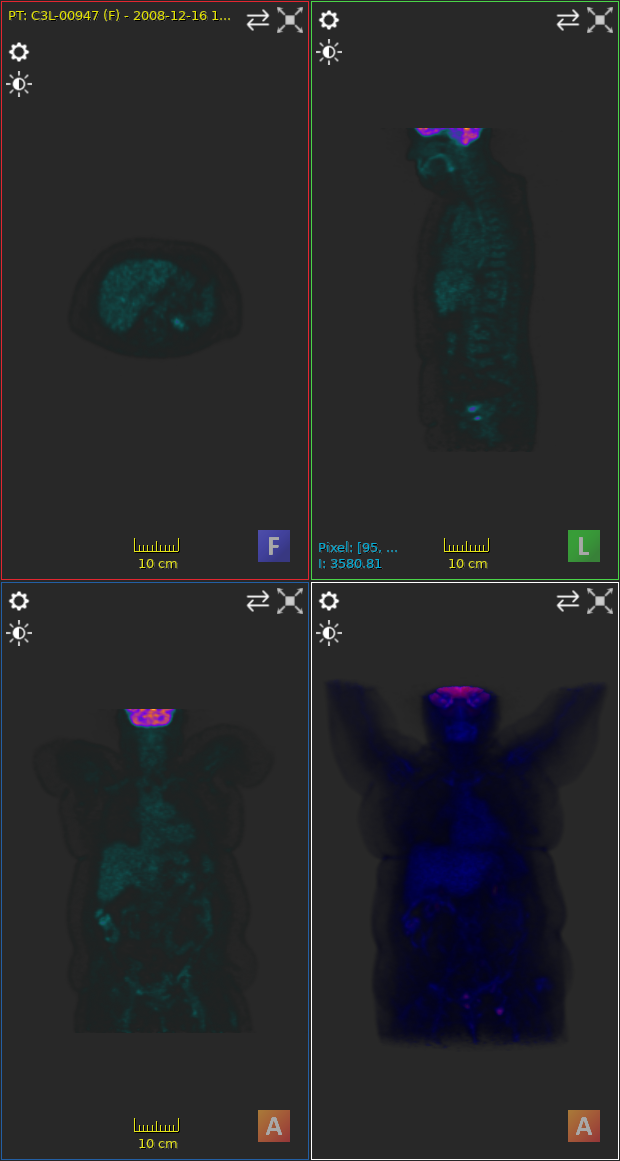

In [6]:
pet_image = pet[0]
array = np.array(pet_image, copy=True)
print(pet_image.shape)

imfusion.show(pet)


Since a `SharedImageSet` is essentially a list of `SharedImage`s, it has an additional leading dimension:
`(frames, slices, height, width, channels)`.

In [7]:
array_set = np.array(pet, copy=False)
print(array_set.shape)

(1, 227, 192, 192, 1)


### Create SharedImage/SharedImageSets from numpy arrays

In [8]:
# SharedImages can be constructed from a rank-4 np.array
array = np.ones((1, 32, 32, 1), dtype=int)
new_image = imfusion.SharedImage(array)
new_set = imfusion.SharedImageSet(new_image)
print(new_set)

# SharedImageSets can be constructed from a rank-5 np.array
array = np.ones((1, 1, 32, 32, 1), dtype=int)
new_sis = imfusion.SharedImageSet(array)
print(new_sis)

imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(DOUBLE width: 32 height: 32)])
imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(DOUBLE width: 32 height: 32)])


### Modifying image data
- `np.array(image, copy=True)` creates a copy. Changes to that array are not reflected in the `SharedImage`.
- `np.array(image, copy=False)` creates a view of the image data, when possible. Changes to that array are reflected in the `SharedImage`.
- To update a `SharedImage` from a copied array, use `assign_array()` to copy the modified data back into the image.

> **Note:** You cannot resize or reshape the image in this way, nor change the type of the image. In such cases, create a new `SharedImage` from the modified NumPy array.

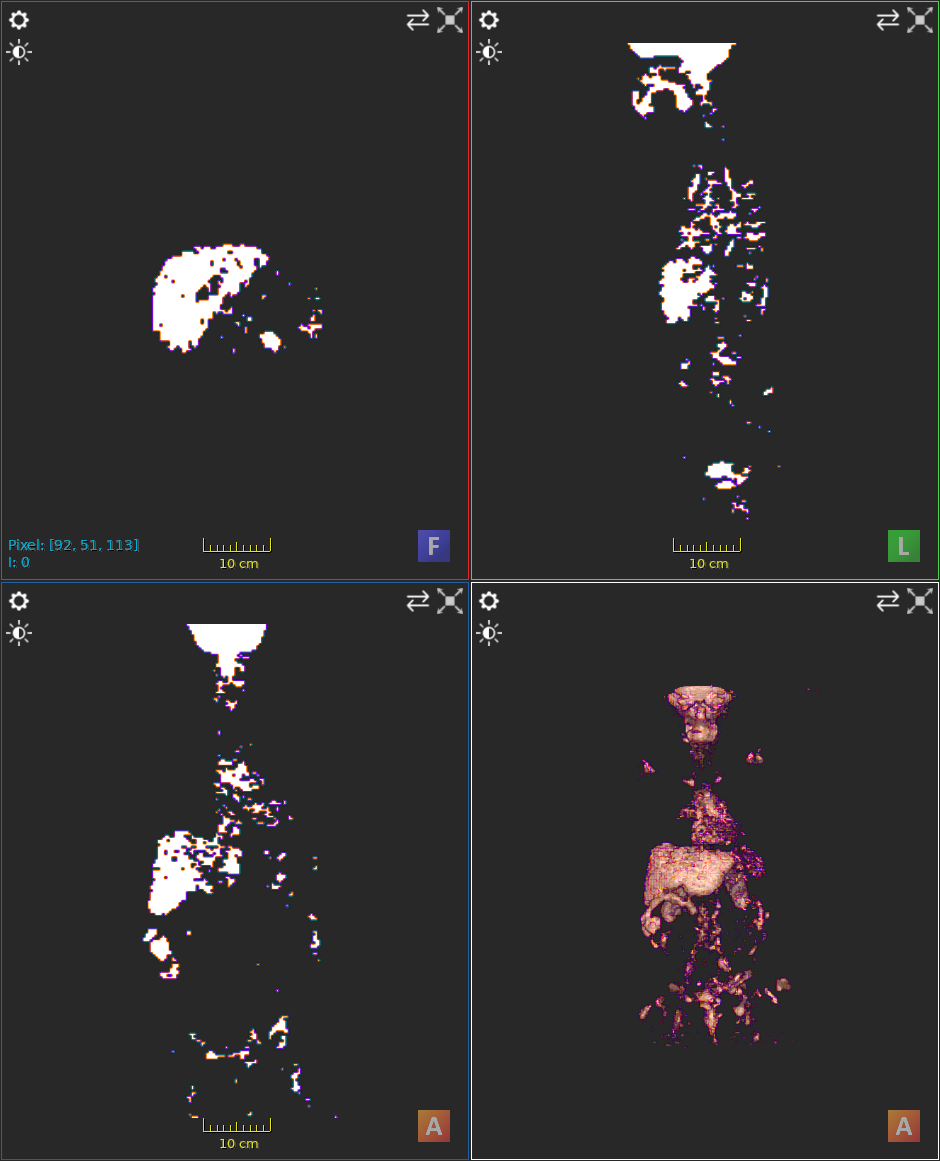

In [9]:
# Create mask by thresholding
pet_image = pet.clone()[0]
array = np.array(pet_image, copy=False)

threshold = 10000
array[array < threshold] = 0
array[array >= threshold] = 1000

pet_image.assign_array(array)
pet_mask = imfusion.SharedImageSet(pet_image)
imfusion.show(pet_mask)

## Saving Images
A list of `SharedImageSet`s can be saved to disk and visualized in the ImFusion Suite.

In [10]:
# The generic `imfusion.io.save` function saves data to ImFusion (`.imf`) files.
imfusion.io.save([imfusion.SharedImageSet(pet_image)], "output/thresholded_pet.imf")